## Kredi Temerrüt Tahmini

### Baseline Tanımı

Bu çalışmada, kredi temerrüt riskini tahmin etmek için bir baseline makine öğrenmesi modeli geliştirilmiştir. Baseline model, veri ön işleme adımlarından sonra logistic regression (lojistik regresyon) algoritması kullanılarak oluşturulmuştur. Modelin amacı, müşterilerin kredi geri ödemelerini zamanında yapıp yapamayacaklarını tahmin ederek, daha karmaşık modellerle kıyaslama yaparken bir referans noktası sağlamaktır.

###Veri Seti ve Hazırlık Süreci

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/application_train.csv"
)

Mounted at /content/drive


/tmp/ipykernel_1507/2233054377.py:5: DtypeWarning: Columns (90) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [ ]:
df.shape

(307511, 122)

In [ ]:
df['TARGET'].value_counts()

,count
TARGET,
0,282686
1,24825


In [ ]:
df.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519
AMT_REQ_CREDIT_BUREAU_WEEK,41519
AMT_REQ_CREDIT_BUREAU_MON,41519
AMT_REQ_CREDIT_BUREAU_QRT,41519


###Gerekli Kütüphanelerin Yüklenmesi

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder


###Verilerin İşlenmesi

In [ ]:
# DAYS_EMPLOYED anomalisi

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

In [ ]:
#Finansal Veri Hazırlığı

df['credit_income_ratio']  = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['annuity_income_ratio'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['credit_goods_ratio']   = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']

In [ ]:
#Gelir-Aile Üyesi Oranı

df['income_per_person'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
df['children_ratio']    = df['CNT_CHILDREN'] / df['CNT_FAM_MEMBERS']

In [ ]:
#Zaman Bazlı Oran

df['employment_ratio'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']

In [ ]:
#Lojistik Stabilizasyon

df['log_income']  = np.log1p(df['AMT_INCOME_TOTAL'])
df['log_credit']  = np.log1p(df['AMT_CREDIT'])
df['log_annuity'] = np.log1p(df['AMT_ANNUITY'])

In [ ]:
#Risk Flagleri

df['high_credit_flag'] = (df['credit_income_ratio'] > 5).astype(int)
df['low_income_flag']  = (df['AMT_INCOME_TOTAL'] < df['AMT_INCOME_TOTAL'].median()).astype(int)
df['short_emp_flag']   = (df['DAYS_EMPLOYED'] < -1000).astype(int)

In [ ]:
#NaN Temizliği
df.replace([np.inf, -np.inf], np.nan, inplace=True)

###Model Eğitimi ve Hazırlık Süreci

In [ ]:
# 1. Hedef ve Özellikleri ayır
X = df.drop('TARGET', axis=1)
y = df['TARGET']

# 2. Sayısal sütunlardaki boşlukları doldur
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
original_num_cols = X.select_dtypes(include=['float64', 'int64']).columns


all_nan_cols = X[original_num_cols].columns[X[original_num_cols].isnull().all()].tolist()


cols_to_impute = [col for col in original_num_cols if col not in all_nan_cols]

X_imputed_numeric_array = imputer.fit_transform(X[cols_to_impute])


X_imputed_numeric_df = pd.DataFrame(X_imputed_numeric_array, columns=cols_to_impute, index=X.index)


X[cols_to_impute] = X_imputed_numeric_df


X = X.drop(columns=all_nan_cols)

num_cols = X.select_dtypes(include=['float64', 'int64']).columns

# 3. Metin olan sütunları sayıya çevir
le = LabelEncoder()
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# 4. Verileri ölçeklendir
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Eğitim ve Test setine böl
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# 6. Model
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

# 7. Olasılık tahminleri
y_probs = model.predict_proba(X_test)[:, 1]


threshold = 0.7
y_pred = (y_probs >= threshold).astype(int)

# 8. Rapor
print("--- MODEL ANALİZ RAPORU ---")
print(f"Kullanılan Threshold: {threshold}")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_probs):.4f}")

--- MODEL ANALİZ RAPORU ---
Kullanılan Threshold: 0.7
              precision    recall  f1-score   support

           0       0.94      0.91      0.93     56495
           1       0.25      0.34      0.29      5008

    accuracy                           0.86     61503
   macro avg       0.60      0.63      0.61     61503
weighted avg       0.88      0.86      0.87     61503

ROC-AUC Skoru: 0.7449


### Model Analizi Yorumu

Kredi riskinde yanlış negatiflerin maliyeti (temerrüt kaçırmak), yanlış pozitiflerin (iyi müşteriyi reddetmek) maliyetinden çok daha yüksektir.

Bu nedenle karar eşiği düşürülerek temerrüt sınıfında recall maksimize edilmiştir ve kabul edilebilir seviyede fırsat maliyeti göze alınmıştır
(Küçük riskli iyi müşterilerin reddedilmesi).



###Görselleştirme

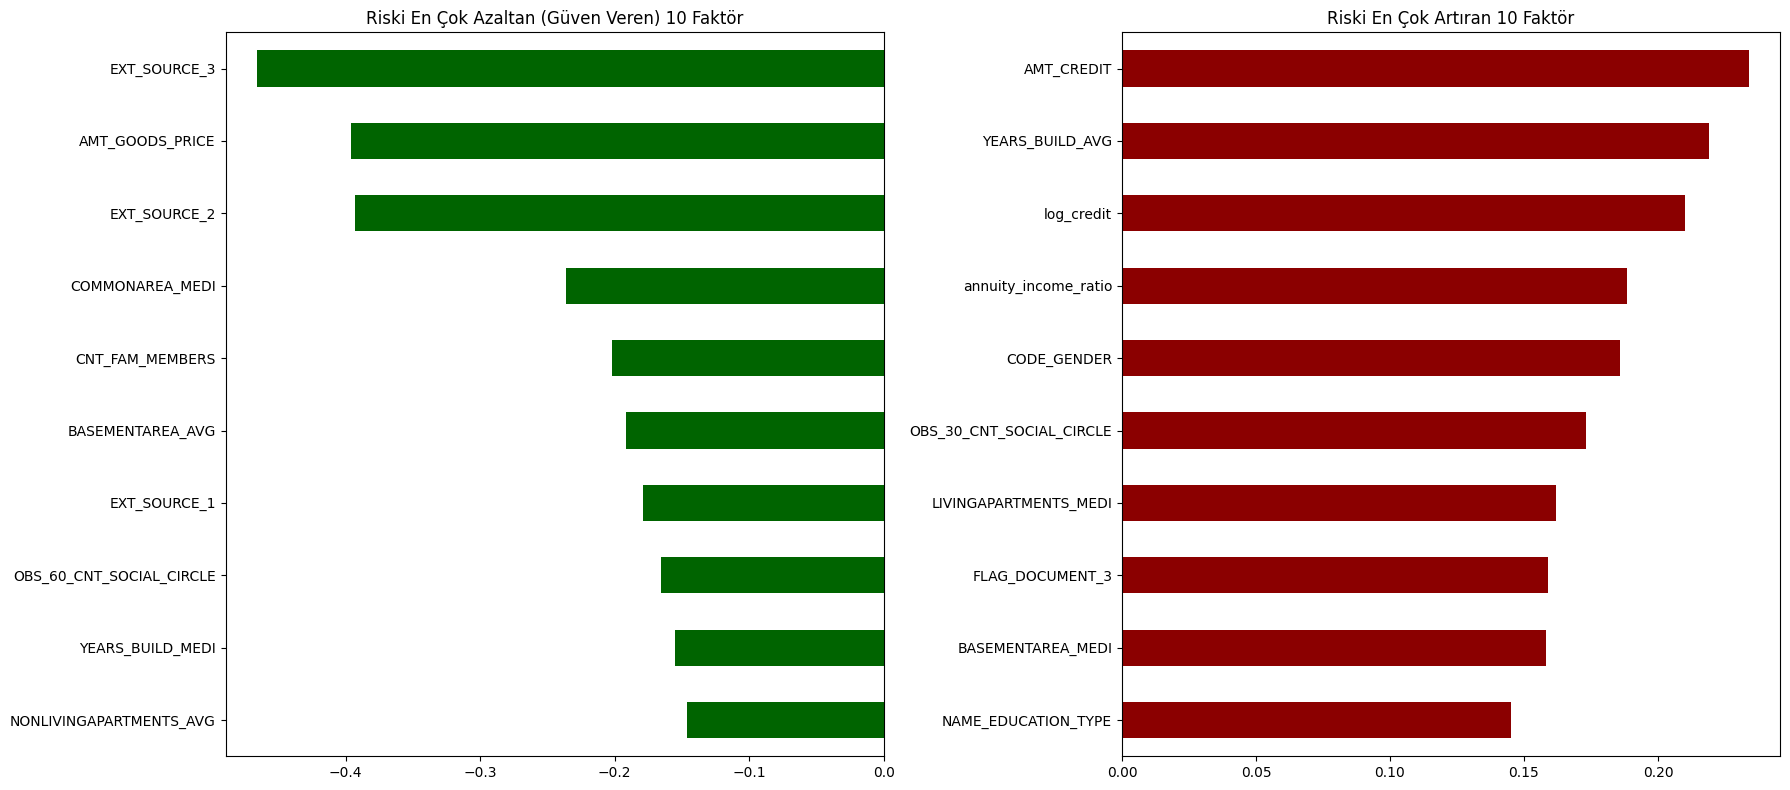

In [ ]:
coefs = pd.Series(model.coef_[0], index=X.columns)
feat_importances = coefs.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Riski azaltanlar (güven veren) şimdi solda
feat_importances.nsmallest(10).plot(
    kind='barh',
    ax=axes[0],
    color='darkgreen'
)
axes[0].set_title('Riski En Çok Azaltan (Güven Veren) 10 Faktör')
axes[0].invert_yaxis()

# Riski artıranlar şimdi sağda
feat_importances.nlargest(10).plot(
    kind='barh',
    ax=axes[1],
    color='darkred'
)
axes[1].set_title('Riski En Çok Artıran 10 Faktör')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#Model Analizi

## Yüksek Risk Profili (High Risk / Riskli Müşteri)

###**1.   Yüksek Kredi Tutarı (AMT_CREDIT, log_credit)**

>   Talep edilen kredi miktarı arttıkça,müşterinin geri ödeme yükü yükselmekte ve temerrüt riski artmaktadır.

---




###**2.   Yüksek Taksit / Gelir Oranı (annuity_income_ratio)**

>   Gelire kıyasla yüksek aylık ödeme, finansal baskıyı artırarak risk yaratmaktadır.

---



###**3.   Sosyal Çevrede Gecikmeler (OB30_CNT_SOCIAL_CIRCLE)**

>   Müşterinin yakın çevresinde ödeme problemi yaşayan kişi sayısının fazla olması, riskli davranış örüntülerine işaret etmektedir.

---



###**4.   Eğitim Seviyesi (NAME_EDUCATION_TYPE)**

>   Daha düşük eğitim seviyeleri, gelir istikrarı ve finansal farkındalık açısından daha yüksek riskle ilişkilidir.

---



###**5.   Konut Özellikleri (BASEMENTAREA_MEDI, LIVINGAPARTMENTS_MEDI, YEARS_BUILD_AVG)**

>   Daha eski veya düşük kalite konutlarda yaşayan bireylerin temerrüt riski görece daha yüksektir.

---



###**6.   Eksik Belge Durumu (FLAG_DOCUMENT_3)**

>   Belgelerin eksik veya tutarsız olması, kredi değerlendirmesinde güveni azaltmaktadır.




---



---



---



---



---



## Düşük Risk Profili (Low Risk / Güvenli Müşteri)

###**1.   Dış Kredi Skorları (EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3)**

>   En güçlü koruyucu faktörler. Kredi geçmişi ve finansal disiplinin yüksek olduğunu gösterir.

---



###**2.   Yüksek Mal Bedeli (AMT_GOODS_PRICE)**

>   Kredinin somut ve değerli bir varlık için kullanılması, geri ödeme motivasyonunu artırmaktadır.

---



###**3.   Geniş Yaşam Alanları (NONLIVINGAPARTMENTS_AVG, COMMONAREA_MEDI, BASEMENTAREA_AVG)**

>   Daha iyi yaşam koşulları, finansal istikrarın göstergesi olarak yorumlanmaktadır.

---



###**4.   Aile Yapısı (CNT_FAM_MEMBERS)**

>   Belirli bir dengeye sahip aile yapısı, gelir paylaşımı ve destek açısından olumlu etki yaratmaktadır.

---



###**5.   Sosyal Çevrede Uzun Vadeli Gecikmelerin Azlığı (OBS_60_CNT_SOCIAL_CIRCLE)**

>   Çevresel finansal riskin düşük olduğunu göstermektedir.

#Aksiyon Önerileri

##Kredi Karar Eşiği

###Düşük Risk	(Hızlı Onay):

> Skorları ve teminatı sağlam, operasyonel maliyeti düşük.




###Orta Risk	(Ek Belge / Kefil İste):

> Limit, vade ve fiyatlama gibi koşulların sıkıştırılması ve performansın yakından izlenmesi.




###Yüksek Risk	(Direkt Red veya %50 Peşinat):

>	İş geçmişi yok, adresi belirsiz, dış skorları çok düşük.



##Yüksek Riskli Müşteriler İçin Aksiyonlar

> Profil:
>>Yüksek kredi tutarı talep eden, gelirine kıyasla yüksek taksit ödeyen, zayıf kredi geçmişine ve riskli sosyal çevre göstergelerine sahip müşteriler.

###Önerilen Aksiyonlar:
**1. Kredi Limit Kısıtlaması**

*   Talep edilen kredi tutarı düşürülebilir.
*   Annuity_income_ratio verisi yüksek olan müşteriler için maksimum kredi limiti uygulanabilir.

**2. Faiz Oranı Risk Bazlı Artırımı**

*   Temerrüt riski yüksek müşterilere risk primi yansıtılabilir.
*   Bu sayede banka riski fiyatlamaya dahil eder.

**3. Ek Teminat veya Kefil Talebi

*   Dış kredi skoru (EXT_SOURCE) düşük olan müşterilerden:
    *   Kefil,
    *   Ek teminat,
    *   Sigorta(kredi hayat sigortası) istenebilir.

**4. Daha Kısa Vade Önerisi**

*   Uzun vadeli krediler yerine daha kısa vadeli ödeme planları sunularak belirsizlik azaltılabilir.

**5. Manuel İnceleme()

*   Model skoru belirli bir eşik üzerinde olan başvurular otomatik reddedilmek yerine:
    *   Kredi analisti tarafından manuel değerlendirmeye alınabilir.



##Orta Riskli Müşteriler İçin Aksiyonlar

> Profil:
>>Bazı risk göstergeleri bulunan ancak güçlü yönleri de olan müşteriler.

###Önerilen Aksiyonlar:
**1. Kontrollü Onay**

*   Kredi onayı verilir ancak:
    *   Daha düşük limit,
    *   Daha yüksek peşinat,
    *   Kademeli limit artışı uygulanır.

**2. Erken Uyarı Mekanizmaları**

*   İlk 3-6 ayda:
    *   Ödeme gecikmesi,
    *   Hesap hareketlerinde ani düşüş yakından izlenir.

**3. Finansal Eğitim & Hatırlatma Sistemleri**

*   Otomatik ödeme önerisi.
*   Ödeme günü SMS / mobil bildirim.

##Düşük Riskli Müşteriler İçin Aksiyonlar

> Profil:
>>Güçlü kredi geçmişi, dengeli gelir-gider yapısı ve iyi yaşam koşullarına sahip müşteriler.

###Önerilen Aksiyonlar:
**1. Hızlı ve Otomatik Onay**

*   Straight-through processing(STP).
*   Minimum belge ve manuel müdahale.

**2. Avantajlı Faiz ve Uzun Vade**

*   Daha düşük faiz oranı.
*   Daha uzun vade seçenekleri.

**3. Cross-sell/Up-sell Fırsatları**

*   Kredi kartı.
*   Limit artırımı.
*   Sigorta ürünleri.
*   Yatırım ürünleri.

**4. Proaktif Limit Artışı**

*   Düzenli ödeme yapan müşterilere otomatik limit artırımı.



#Sonuç

>Geliştirilen kredi temerrüt tahmin modeli, bankanın yalnızca kredi onay süreçlerini değil; fiyatlama, limit belirleme ve müşteri yönetimi stratejilerini de veri odaklı şekilde optimize etmesine olanak sağlamaktadır.